# 03 - Simple RNN
Baseline RNN, no attention, no explicit encoder/decoder separation.

In [9]:
import sys, os, json, pickle, random, math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

sys.path.append("../src")
import config
from dataset import TranslationDataset, create_collate_fn
from models.rnn import EncoderRNN, DecoderRNN, Seq2SeqRNN
from train import train_epoch, evaluate
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from evaluate import translate_sentence

random.seed(config.ROLL_NUMBER)
np.random.seed(config.ROLL_NUMBER)
torch.manual_seed(config.ROLL_NUMBER)
device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: mps


## Load data

In [10]:
train_df = pd.read_csv("../data/processed/train.csv")
val_df = pd.read_csv("../data/processed/validation.csv")
test_df = pd.read_csv("../data/processed/test.csv")

english_vocab = pickle.load(open("../data/processed/english_vocab.pkl", "rb"))
spanish_vocab = pickle.load(open("../data/processed/spanish_vocab.pkl", "rb"))

pad_en = english_vocab.word2idx["<pad>"]
pad_es = spanish_vocab.word2idx["<pad>"]
collate_fn = create_collate_fn(pad_en, pad_es)

train_dataset = TranslationDataset(train_df, english_vocab, spanish_vocab)
val_dataset = TranslationDataset(val_df, english_vocab, spanish_vocab)
test_dataset = TranslationDataset(test_df, english_vocab, spanish_vocab)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

## Build model

In [11]:
MODEL_NAME = "Simple RNN"
MODEL_KEY = "rnn"
CHECKPOINT_PATH = "../models/rnn_model.pt"

encoder = EncoderRNN(len(english_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
decoder = DecoderRNN(len(spanish_vocab), config.EMB_DIM, config.HIDDEN_DIM, dropout_p=config.DROPOUT)
model = Seq2SeqRNN(encoder, decoder, device).to(device)

## Train

In [12]:
criterion = nn.CrossEntropyLoss(ignore_index=pad_es)
optimizer = optim.Adam(model.parameters(), lr=config.LEARNING_RATE)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

best_val_loss = float("inf")
os.makedirs("../models", exist_ok=True)
history = {"train_loss": [], "val_loss": []}

for epoch in range(config.N_EPOCHS):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device, teacher_forcing_ratio=config.TEACHER_FORCING_RATIO)
    val_loss = evaluate(model, val_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)

    print(f"Epoch: {epoch+1:02} | Train Loss: {train_loss:.3f} | Val Loss: {val_loss:.3f}")

Trainable params: 3014450
Epoch: 01 | Train Loss: 5.239 | Val Loss: 5.081
Epoch: 02 | Train Loss: 4.857 | Val Loss: 5.061
Epoch: 03 | Train Loss: 4.685 | Val Loss: 4.924
Epoch: 04 | Train Loss: 4.531 | Val Loss: 4.880
Epoch: 05 | Train Loss: 4.458 | Val Loss: 4.910
Epoch: 06 | Train Loss: 4.372 | Val Loss: 4.995
Epoch: 07 | Train Loss: 4.328 | Val Loss: 4.900
Epoch: 08 | Train Loss: 4.289 | Val Loss: 4.947
Epoch: 09 | Train Loss: 4.241 | Val Loss: 4.952
Epoch: 10 | Train Loss: 4.230 | Val Loss: 4.999


## Loss curve

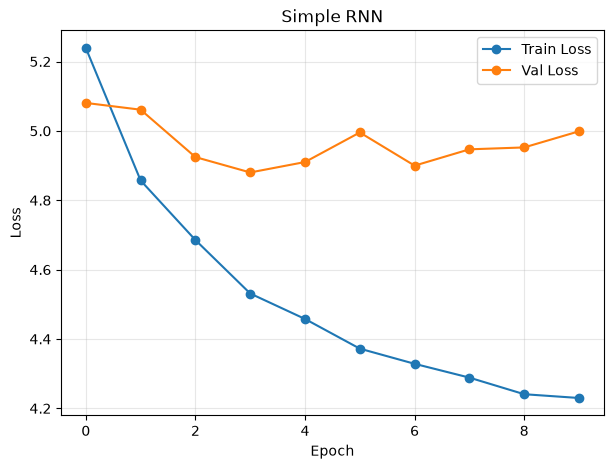

In [13]:
plt.figure(figsize=(7, 5))
plt.plot(history["train_loss"], label="Train Loss", marker="o")
plt.plot(history["val_loss"], label="Val Loss", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(MODEL_NAME)
plt.legend()
plt.grid(alpha=0.3)
os.makedirs("../results/figures", exist_ok=True)
plt.savefig(f"../results/figures/{MODEL_KEY}_loss.png", dpi=150, bbox_inches="tight")
plt.show()

## Test evaluation

In [14]:
# Load optimal checkpoint weights
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))

test_loss = evaluate(model, test_loader, criterion, device)
test_ppl = math.exp(test_loss)

print(f"Test Loss: {test_loss:.3f}")
print(f"Test Perplexity: {test_ppl:.3f}")

smooth = SmoothingFunction().method1
references = []
hypotheses = []

for _, row in test_df.iterrows():
    src_text = row["english"]
    trg_text = row["spanish"]

    pred_text, _ = translate_sentence(src_text, english_vocab, spanish_vocab, model, device, max_len=config.MAX_DECODE_LEN)

    references.append([spanish_vocab.tokenize(trg_text)])
    hypotheses.append(pred_text.split())

bleu1 = corpus_bleu(references, hypotheses, weights=(1.0, 0, 0, 0), smoothing_function=smooth) * 100
bleu4 = corpus_bleu(references, hypotheses, weights=(0.25, 0.25, 0.25, 0.25), smoothing_function=smooth) * 100

print(f"{MODEL_NAME} Corpus BLEU-1 Score: {bleu1:.2f}")
print(f"{MODEL_NAME} Corpus BLEU-4 Score: {bleu4:.2f}")

results = {
    "model": MODEL_NAME,
    "params": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "test_loss": round(test_loss, 3),
    "test_ppl": round(test_ppl, 3),
    "bleu1": round(bleu1, 2),
    "bleu4": round(bleu4, 2),
}
print(results)

os.makedirs("../results/tables", exist_ok=True)
json.dump(results, open(f"../results/tables/{MODEL_KEY}_results.json", "w"))
json.dump(history, open(f"../results/tables/{MODEL_KEY}_history.json", "w"))

Test Loss: 4.941
Test Perplexity: 139.910
Simple RNN Corpus BLEU-1 Score: 23.93
Simple RNN Corpus BLEU-4 Score: 0.05
{'model': 'Simple RNN', 'params': 3014450, 'test_loss': 4.941, 'test_ppl': 139.91, 'bleu1': 23.93, 'bleu4': 0.05}


## Sample translations

In [15]:
samples = [
    "I am a student.",
    "She is reading a book in the library.",
    "We need to protect our environment.",
    "Can you help me solve this problem?",
]
for s in samples:
    translation, _ = translate_sentence(s, english_vocab, spanish_vocab, model, device, max_len=config.MAX_DECODE_LEN)
    print(f"EN: {s}\n-> {translation}\n")

EN: I am a student.
-> tom no que que de que <unk> .

EN: She is reading a book in the library.
-> tom no que que de que <unk> .

EN: We need to protect our environment.
-> tom no que que de que <unk> .

EN: Can you help me solve this problem?
-> ¿ qué qué ?

